# Imports

In [1]:
import os
import duckdb
from pathlib import Path
import dotenv

In [2]:
dotenv.load_dotenv()
STORE_DIR = Path(os.getenv("CICCADA_SYNTHETIC_AMI_DATA_ROOT"))
con = duckdb.connect()

# 1. Meter dataset description

## 1.1. Single site exploration

In [3]:
TABLE = "ami_meter"

list_random = con.sql(f"""
    SELECT DISTINCT site_id FROM read_parquet(
        '{(STORE_DIR / TABLE).as_posix()}/dt_month=*/*.parquet', hive_partitioning=1)
    LIMIT 20
""").df()

list_random

,site_id
0,482308698
1,484362951
2,486560669
3,488872552
4,497520152
5,497604455
6,497649279
7,505318625
8,699490037
9,703415326


In [4]:
# Example A: (1 pv_site_net + 1 ac_load_net)
SITE_ID = 931508817

# Example B: (3 pv_site_net + 3 ac_load_net)
# SITE_ID = 941652668

# Example C: (3 pv_site_net + 1 ac_load_net)
# SITE_ID = 1252334806

# Example D: (1 pv_site_net + 3 ac_load_net)
# SITE_ID = 771838743

# Site with load_other
# SITE_ID = 1030834588

In [5]:
def read_table(table_name, site_id=SITE_ID):
    return con.sql(f"""
        SELECT * FROM read_parquet('{(STORE_DIR / table_name).as_posix()}/dt_month=*/*.parquet',
                                    hive_partitioning=1)
        WHERE site_id = {site_id}
        ORDER BY t_stamp
    """).df()

In [6]:
df_meter = read_table(TABLE)

In [7]:
df_meter

,site_id,device_id,circuit_id,t_stamp,year,month,V,P_kw,Q_kvar,S_kva,power_factor,current_a,energy_import_kwh,energy_export_kwh,dt_month
0,931508817,107082,515632,2024-01-01 00:00:00,2024,1,243.55,-0.859673,-0.227543,0.889277,0.934528,3.7715,0.000000,0.071639,2024-01
1,931508817,107082,515632,2024-01-01 00:05:00,2024,1,242.80,-0.828070,-0.202003,0.852353,0.943833,3.6730,0.000000,0.069006,2024-01
2,931508817,107082,515632,2024-01-01 00:10:00,2024,1,243.35,-0.894660,-0.201080,0.916979,0.951914,3.8985,0.000000,0.074555,2024-01
3,931508817,107082,515632,2024-01-01 00:15:00,2024,1,241.25,-0.738620,-0.202423,0.765856,0.930140,3.4115,0.000000,0.061552,2024-01
4,931508817,107082,515632,2024-01-01 00:20:00,2024,1,242.40,-0.971220,-0.211354,0.993951,0.954784,4.5885,0.000000,0.080935,2024-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178986,931508817,107082,515632,2025-11-18 06:55:00,2025,11,245.75,-0.001087,-0.404410,0.404411,0.000007,6.1525,0.007636,0.007726,2025-11
178987,931508817,107082,515632,2025-11-18 07:00:00,2025,11,244.10,0.012187,-0.402713,0.402897,0.000915,6.0255,0.007896,0.006880,2025-11
178988,931508817,107082,515632,2025-11-18 07:05:00,2025,11,242.65,0.031850,-0.397354,0.398628,0.006384,6.2885,0.008846,0.006192,2025-11
178989,931508817,107082,515632,2025-11-18 07:10:00,2025,11,242.25,0.025500,-0.437473,0.438216,0.003386,6.1535,0.008662,0.006537,2025-11


In [8]:
from datetime import timedelta

df_meter["t_stamp"] = df_meter["t_stamp"] + timedelta(hours=10)

In [9]:
df_day_meter = df_meter[(df_meter["t_stamp"] >= "2025-01-15") & (df_meter["t_stamp"] < "2025-01-16")]

In [10]:
df_day_meter

,site_id,device_id,circuit_id,t_stamp,year,month,V,P_kw,Q_kvar,S_kva,power_factor,current_a,energy_import_kwh,energy_export_kwh,dt_month
109278,931508817,107082,515632,2025-01-15 00:00:00,2025,1,241.85,0.732247,-0.552520,0.917313,0.637206,4.0715,0.061021,0.0,2025-01
109279,931508817,107082,515632,2025-01-15 00:05:00,2025,1,242.30,0.738137,-0.457140,0.868230,0.722777,3.9725,0.061511,0.0,2025-01
109280,931508817,107082,515632,2025-01-15 00:10:00,2025,1,239.80,0.583727,-0.363890,0.687861,0.720141,2.9145,0.048644,0.0,2025-01
109281,931508817,107082,515632,2025-01-15 00:15:00,2025,1,237.65,0.573333,-0.356587,0.675178,0.721071,2.8970,0.047778,0.0,2025-01
109282,931508817,107082,515632,2025-01-15 00:20:00,2025,1,239.60,0.472287,-0.403640,0.621273,0.577891,2.7640,0.039357,0.0,2025-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109561,931508817,107082,515632,2025-01-15 23:35:00,2025,1,245.20,0.624827,-0.275906,0.683032,0.836830,2.7980,0.052069,0.0,2025-01
109562,931508817,107082,515632,2025-01-15 23:40:00,2025,1,244.60,0.625487,-0.275527,0.683483,0.837492,2.8040,0.052124,0.0,2025-01
109563,931508817,107082,515632,2025-01-15 23:45:00,2025,1,244.95,0.619093,-0.277187,0.678313,0.833012,2.7835,0.051591,0.0,2025-01
109564,931508817,107082,515632,2025-01-15 23:50:00,2025,1,244.95,0.612943,-0.277337,0.672767,0.830064,2.7640,0.051079,0.0,2025-01


In [11]:
df_day_meter['circuit_id'].unique()

array([515632])

Text(0.5, 0, 'Timestamp')

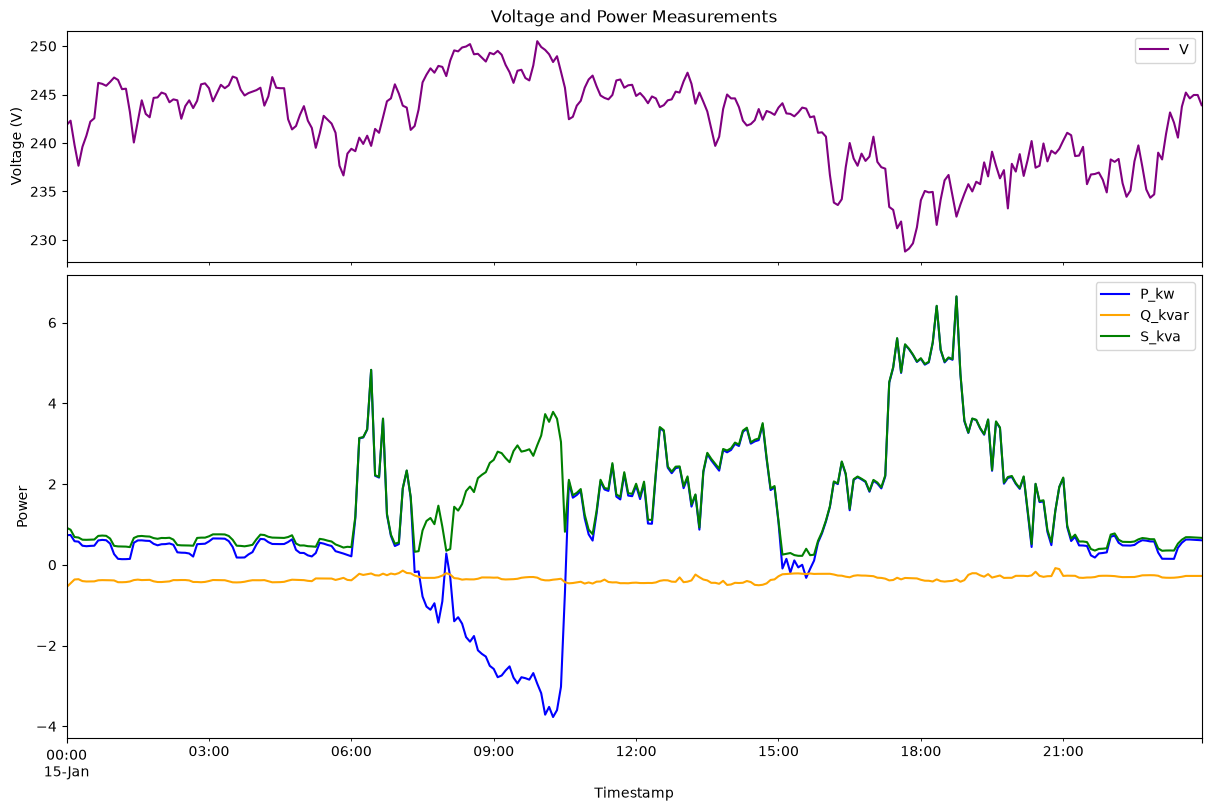

In [12]:
import matplotlib.pyplot as plt

fig, (ax_voltage, ax_power) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(12, 8),
    constrained_layout=True,
    gridspec_kw={"height_ratios": [1, 2]},
)

df_day_meter.plot(
    x="t_stamp",
    y="V",
    kind="line",
    ax=ax_voltage,
    color="purple",
    title="Voltage and Power Measurements",
    ylabel="Voltage (V)",
)

df_day_meter.plot(
    x="t_stamp",
    y=["P_kw", "Q_kvar", "S_kva"],
    kind="line",
    ax=ax_power,
    color=["blue", "orange", "green"],
    ylabel="Power",
)

ax_power.set_xlabel("Timestamp")

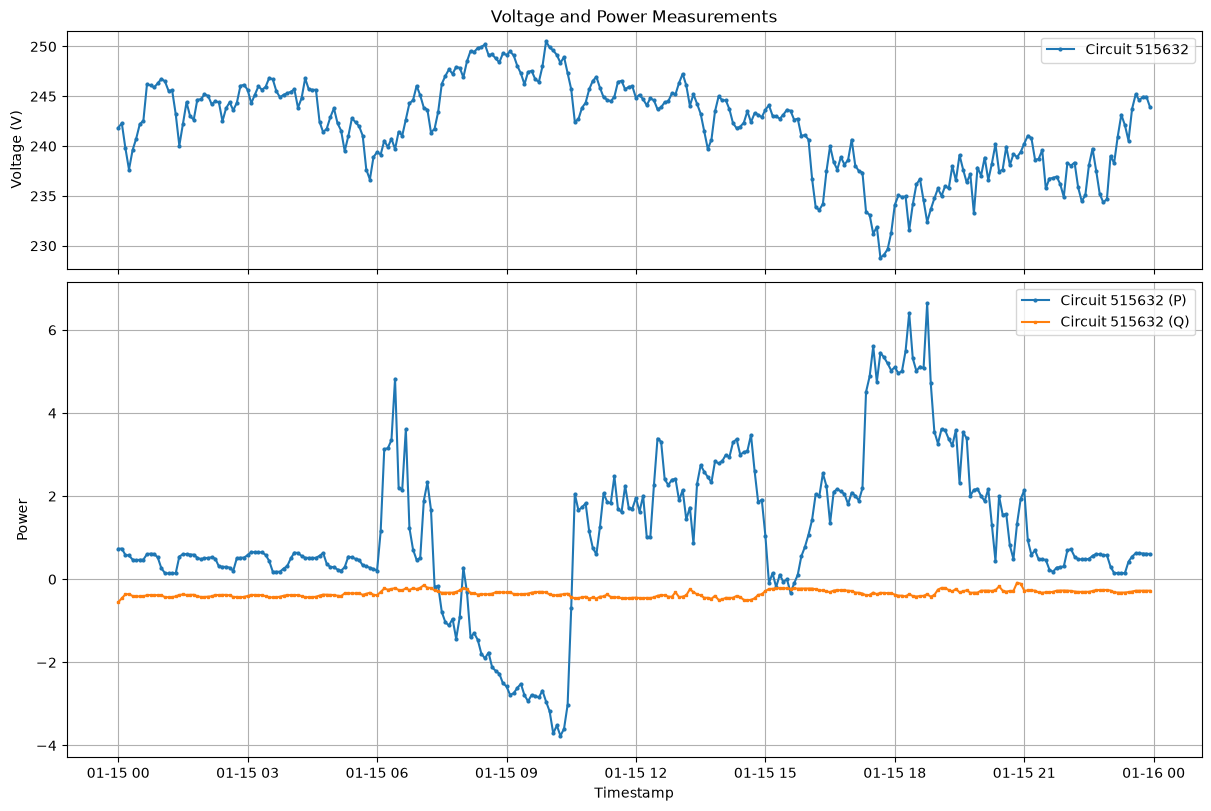

In [13]:
fig, (ax_voltage, ax_power) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(12, 8),
    constrained_layout=True,
    gridspec_kw={"height_ratios": [1, 2]},
)

# Plot voltage by circuit_id
for circuit_id in df_day_meter['circuit_id'].unique():
    mask = df_day_meter['circuit_id'] == circuit_id
    ax_voltage.plot(
        df_day_meter.loc[mask, 't_stamp'],
        df_day_meter.loc[mask, 'V'],
        label=f'Circuit {circuit_id}',
        marker='o',
        markersize=2,
    )

ax_voltage.set_ylabel("Voltage (V)")
ax_voltage.set_title("Voltage and Power Measurements")
ax_voltage.legend()
ax_voltage.grid(True)

# Plot power by circuit_id
for circuit_id in df_day_meter['circuit_id'].unique():
    mask = df_day_meter['circuit_id'] == circuit_id
    ax_power.plot(
        df_day_meter.loc[mask, 't_stamp'],
        df_day_meter.loc[mask, 'P_kw'],
        label=f'Circuit {circuit_id} (P)',
        marker='o',
        markersize=2,
    )
    ax_power.plot(
        df_day_meter.loc[mask, 't_stamp'],
        df_day_meter.loc[mask, 'Q_kvar'],
        label=f'Circuit {circuit_id} (Q)',
        marker='s',
        markersize=2,
    )

ax_power.set_ylabel("Power")
ax_power.set_xlabel("Timestamp")
ax_power.legend()
ax_power.grid(True)

# 2. Meter data description

In [14]:
con.sql(f"""
    CREATE OR REPLACE VIEW ami_meter AS
    SELECT * FROM read_parquet(
        '{(STORE_DIR / "ami_meter").as_posix()}/dt_month=*/*.parquet',
        hive_partitioning=1
    )
""")

In [15]:
con.sql("SELECT count(*) AS n_rows, count(DISTINCT site_id) AS n_sites FROM ami_meter").df()

,n_rows,n_sites
0,1492262979,10405


In [16]:
summary = con.sql("SUMMARIZE ami_meter").df()
summary

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,site_id,BIGINT,130538,2147365813,12006,1078055492.7580822,618918459.808252,547035936,1069806817,1616690207,1492262979,0.00
1,device_id,BIGINT,88938,230968,9380,122429.66058813686,26213.63043705875,105040,117448,129891,1492262979,0.00
2,circuit_id,BIGINT,5749,707582,14695,443842.62448734714,126113.9983331085,348267,448808,538879,1492262979,0.00
3,t_stamp,TIMESTAMP,2024-01-01 00:00:00,2025-12-31 23:55:00,235997,2024-12-04 16:37:46.233797,NaN,2024-06-09 21:00:26.667312,2024-11-24 03:14:44.559667,2025-05-19 06:42:45.193602,1492262979,0.00
4,year,INTEGER,2024,2025,2,2024.4402532799147,0.4964174952651707,2024,2024,2025,1492262979,0.00
5,month,INTEGER,1,12,13,6.348033623636521,3.50644417306653,3,6,9,1492262979,0.00
6,V,DOUBLE,0.0,429496.7,17466,247.41432582682455,1386.2247009499051,237.8286226903019,241.02788074760613,244.00775565322112,1492262979,0.00
7,P_kw,DOUBLE,-368.31714669999997,798.12816,15617714,0.05139496899919882,3.0606281931681725,-0.3453215299176774,0.16026754103382276,0.582090761985645,1492262979,0.00
8,Q_kvar,DOUBLE,-227.3370672,3119.5932900000003,9416912,0.01978444123091479,1.1738423352301768,-0.3229682751293159,-0.11838141965977533,0.1577067015592305,1492262979,0.00
9,S_kva,DOUBLE,0.0,3119.5948508531437,1363059053,1.4905843788570077,2.9200809650829984,0.33443950163676717,0.701368003554347,1.7498294153567364,1492262979,0.00


In [17]:
# e.g. per-site summary stats, not raw rows
site_summary = con.sql("""
    SELECT site_id, count(*) AS n_rows, count(DISTINCT circuit_id) AS n_phases,
           min(t_stamp) AS first_seen, max(t_stamp) AS last_seen,
           avg(P_kw) AS mean_P_kw
    FROM ami_meter GROUP BY site_id
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [18]:
import sys
from pathlib import Path

_current = Path.cwd().resolve()
REPO_ROOT = next((p for p in (_current, *_current.parents) if (p / "bms_sa_review").is_dir()), None)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from bms_sa_review.synthetic_ami_creation.config import ami_config as Config
import pandas as pd

site_metadata = pd.read_csv(Config.ARTEFACT_DIR / "phase5_site_metadata_full_fleet.csv")
site_metadata.head()

,site_id,state,postcode,dnsp_name,ac_capacity_kw,dc_capacity_kw,export_limit_kw,inverter_count,voltage_class,manufacturer,model,flex_export_detected,monitoring_start,pv_install_date,kept_circuit_ids,dropped_circuits,device_id_groups,needs_manual_review
0,1233585204,VIC,3140,Ausnet,5.0,5.10,NaN,1.0,neutral-absorb,Growatt,5000MTL,False,2019-08-09,2019-08-08,[],"[{'circuit_id': 219150, 'reason': 'duplicate_s...",{},True
1,158521185,NSW,2488,Essential,8.0,10.54,NaN,1.0,absorb,Sungrow,SG8K-D,False,2019-10-31,2019-10-30,"[239893, 239896]",[],"{121143: [239893, 239896]}",False
2,2083958230,NSW,2763,Endeavour,5.0,5.28,NaN,1.0,neutral-absorb,Generic Inverter,5kW,True,2020-01-07,2019-12-13,"[254725, 254726]",[],"{105994: [254725, 254726]}",False
3,248529252,VIC,3140,Ausnet,5.0,5.06,NaN,1.0,neutral-absorb,Generic Inverter,5kW,False,2020-03-04,2020-03-04,"[276766, 276767, 276768, 276769]",[],"{127872: [276766, 276767, 276768, 276769]}",False
4,804338564,QLD,4670,Ergon,5.0,5.28,NaN,1.0,neutral-absorb,SMA,Sunny Boy 5.0,False,2020-06-10,2020-06-09,"[298417, 298418]",[],"{132056: [298417, 298418]}",False


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

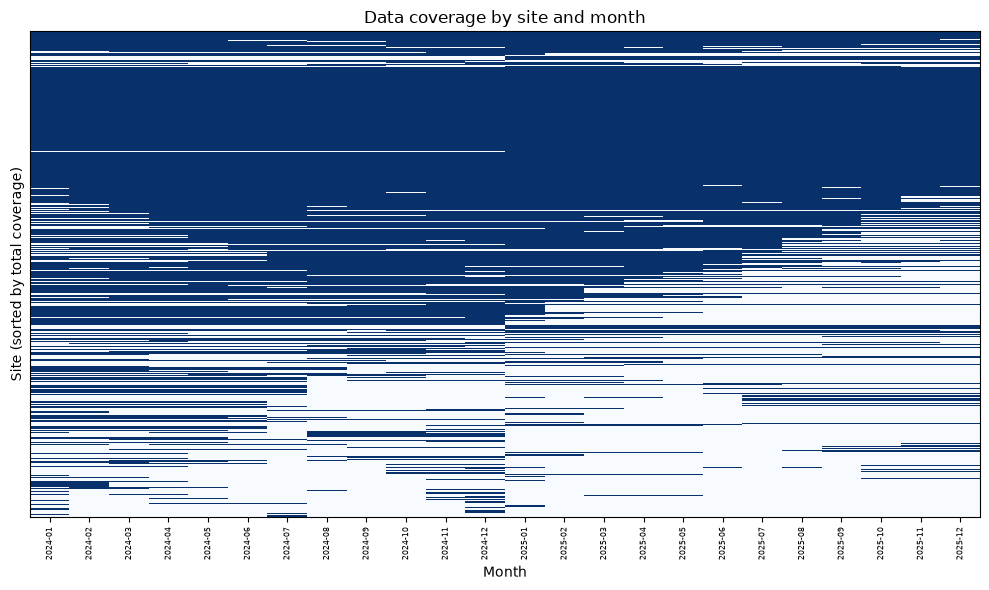

In [19]:
import matplotlib.pyplot as plt
import numpy as np

coverage = con.sql("""
    SELECT site_id, year, month, count(*) AS n_rows
    FROM ami_meter GROUP BY site_id, year, month
""").df()
coverage["ym"] = coverage.year.astype(str) + "-" + coverage.month.astype(str).str.zfill(2)

pivot = coverage.pivot_table(index="site_id", columns="ym", values="n_rows", fill_value=0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]  # order by total coverage

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values > 0, aspect="auto", cmap="Blues", interpolation="none")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=90, fontsize=6)
ax.set_yticks([])
ax.set_xlabel("Month")
ax.set_ylabel("Site (sorted by total coverage)")
ax.set_title("Data coverage by site and month")
fig.tight_layout()
fig.savefig("coverage_heatmap.png", dpi=200)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

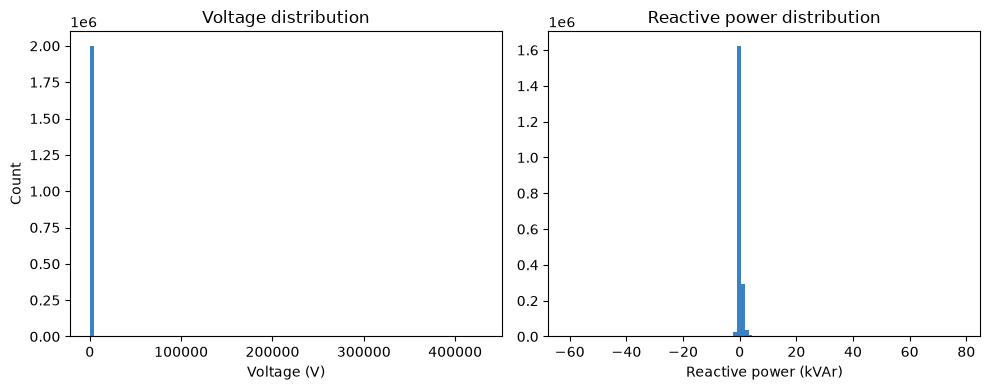

In [20]:
sample = con.sql("""
    SELECT V, Q_kvar FROM ami_meter
    USING SAMPLE 2000000 ROWS
""").df()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(sample["V"].dropna(), bins=100, color="#3B82C4")
axes[0].set_xlabel("Voltage (V)")
axes[0].set_ylabel("Count")
axes[0].set_title("Voltage distribution")

axes[1].hist(sample["Q_kvar"].dropna(), bins=100, color="#3B82C4")
axes[1].set_xlabel("Reactive power (kVAr)")
axes[1].set_title("Reactive power distribution")

fig.tight_layout()
fig.savefig("voltage_reactive_distributions.png", dpi=200)